In [182]:
import numpy as np
import matplotlib.pyplot as plt
import utils
import ot
import scipy
import os
import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
p = "datasets/action_smplx_models/male_run.npz"
mesh1 = utils.mesh_from_path(p, idx = 0)
mesh2 = utils.mesh_from_path(p, idx = 10)

In [3]:
N = 1000
points1, faces1 = utils.sampled_verts_from_mesh(mesh1, n_points=N, return_faces=True)
points2, faces2 = utils.sampled_verts_from_mesh(mesh2, n_points=N, return_faces=True)

In [4]:
C1 = scipy.spatial.distance_matrix(points1, points1)
C2 = scipy.spatial.distance_matrix(points2, points2)
M = ot.dist(points1, points2)
a = np.ones(N) / N
b = np.ones(N) / N

In [5]:
G = ot.sinkhorn(a, b, M, reg = 1)

In [6]:
def rowwise_argmax_onehot(A):
    """
    Replace each row of A with a one-hot vector that has a 1
    at the index of the maximum entry of that row.
    """
    A = np.asarray(A)
    out = np.zeros_like(A)
    out[np.arange(A.shape[0]), np.argmax(A, axis=1)] = 1
    return out

In [7]:
G_new = rowwise_argmax_onehot(G)

In [8]:
((G_new.T / G_new.max()) @ faces1).astype(int)

array([     0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,   8733,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0, 126513,   4629,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,  16582,      0,      0,      0,
            0,      0,  25141,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,  47973,      0,
            0,  16976,      0,  15228,      0,      0,      0,      0,
            0,  16872,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,  14250,      0,      0,      0,      0,      0,      0,
      

In [ ]:
ot.solve(M, a, b)

OTResult(value=0.10528673487919887,value_linear=0.10528673487919887,plan=ndarray(shape=(10000, 10000)))

In [ ]:
region_accuracies = []
region_accuracies_adjusted = []
average_region_distances = []
alphas = np.arange(0, 1.01, 0.05)
Gs = []
for alpha in alphas:
    G = ot.fused_gromov_wasserstein(M, C1, C2, alpha = alpha)
    Gs.append(G)
    region_accuracies.append(utils.region_accuracy(G, faces1, faces2))
    region_accuracies_adjusted.append(utils.region_accuracy_adjusted(G, faces1, faces2))
    average_region_distances.append(utils.average_region_distance(G, faces1, faces2))

c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\ot\lp\__init__.py:388: UserWarning:

numItermax reached before optimality. Try to increase numItermax.



KeyboardInterrupt: 

Text(0.5, 0, 'Alpha (FGW)')

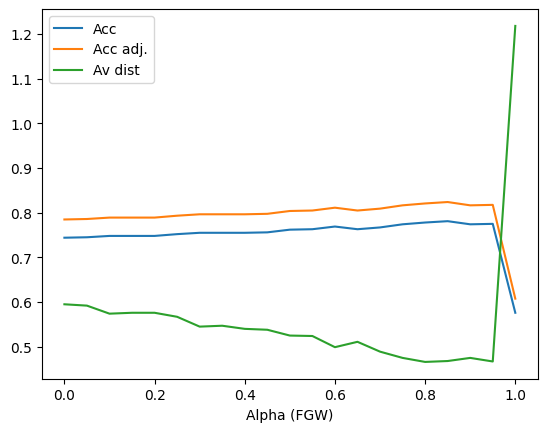

In [ ]:
plt.plot(alphas, region_accuracies, label = "Acc")
plt.plot(alphas, region_accuracies_adjusted, label = "Acc adj.")
plt.plot(alphas, average_region_distances, label = "Av dist")
plt.legend()
plt.xlabel("Alpha (FGW)")

In [ ]:
utils.plot_3d_points_and_connections_region_matched(points1, points2, faces1, faces2, Gs[0], plot_both=False)

Region accuracy: 0.744


In [ ]:
utils.plot_3d_points_and_connections_region_matched(points1, points2, faces1, faces2, Gs[-4], plot_both=False)

Region accuracy: 0.781


In [ ]:
region_accuracies

[0.744,
 0.745,
 0.748,
 0.748,
 0.748,
 0.752,
 0.755,
 0.755,
 0.755,
 0.756,
 0.762,
 0.763,
 0.769,
 0.763,
 0.767,
 0.774,
 0.778,
 0.781,
 0.774,
 0.775,
 0.576]

In [ ]:
import numpy as np
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components, dijkstra

def graph_distance_within_cloud_minimally_connected(P, k=3):
    """
    Construct a minimally connected kNN graph on two point clouds
    and compute graph distances.

    Parameters
    ----------
    P, Q : (N, 3) numpy arrays
        Two point clouds of equal size
    k : int
        Number of nearest neighbors (default: 3)

    Returns
    -------
    D : (N, N) numpy array
        Graph distance matrix from P to Q
    """
    P = np.asarray(P)

    N = P.shape[0]
    X = P         # (2N, 3)
    M = N

    # --- Step 1: initial kNN graph ---
    tree = cKDTree(X)
    dists, nbrs = tree.query(X, k=k + 1)

    edges = {}  # (i, j) -> weight
    for i in range(M):
        for j, dist in zip(nbrs[i][1:], dists[i][1:]):
            a, b = sorted((i, j))
            edges[(a, b)] = dist

    # --- Step 2: minimally connect components ---
    while True:
        rows, cols, weights = [], [], []
        for (i, j), w in edges.items():
            rows += [i, j]
            cols += [j, i]
            weights += [w, w]

        A = coo_matrix((weights, (rows, cols)), shape=(M, M))
        n_components, labels = connected_components(A, directed=False)

        if n_components == 1:
            break

        # pick one component
        c0 = labels[0]
        idx_c0 = np.where(labels == c0)[0]
        idx_rest = np.where(labels != c0)[0]

        # find closest inter-component pair
        P0 = X[idx_c0]
        P1 = X[idx_rest]

        dmat = np.linalg.norm(P0[:, None, :] - P1[None, :, :], axis=2)
        i_min, j_min = np.unravel_index(np.argmin(dmat), dmat.shape)

        u = idx_c0[i_min]
        v = idx_rest[j_min]
        w = dmat[i_min, j_min]

        a, b = sorted((u, v))
        edges[(a, b)] = w

    # --- Step 3: shortest-path distances ---
    rows, cols, weights = [], [], []
    for (i, j), w in edges.items():
        rows += [i, j]
        cols += [j, i]
        weights += [w, w]

    A = coo_matrix((weights, (rows, cols)), shape=(M, M))

    # distances from P nodes (0..N-1) to all nodes
    dist_full = dijkstra(A, directed=False, indices=np.arange(N))

    # extract P -> P distances
    D = dist_full

    return D


In [ ]:
points1, faces1 = utils.sampled_verts_from_path("datasets/action_smplx_models/male_run.npz", idx = 0, return_faces=True)
points2, faces2 = utils.sampled_verts_from_path("datasets/action_smplx_models/male_run.npz", idx = 50, return_faces=True)

In [ ]:
C1 = graph_distance_within_cloud_minimally_connected(points1)
C2 = graph_distance_within_cloud_minimally_connected(points2)

In [18]:
a = np.ones(1000) / 1000
b = np.ones(1000) / 1000
G = ot.gromov_wasserstein(C1, C2, a, b)

In [20]:
utils.region_accuracy_adjusted(G, faces1, faces2)

np.float64(0.6181229773462783)

In [21]:
utils.plot_3d_points_and_connections_region_matched(points1, points2, faces1, faces2, G)

Region accuracy adjusted: 0.6181229773462783


In [36]:
lifted1 = utils.lift_with_symmetry(points1, utils.pca_symmetry_plane(points1))
lifted2 = utils.lift_with_symmetry(points2, utils.pca_symmetry_plane(points2))
M = ot.dist(lifted1, lifted2)

In [59]:
meshes = [utils.mesh_from_path("datasets/action_smplx_models/female_run.npz", idx = i) for i in np.arange(0, 101, 10)]
points1, faces1 = utils.sampled_verts_from_mesh(meshes[0], return_faces = True)
lifted1 = utils.lift_with_symmetry(points1, utils.pca_symmetry_plane(points1))
C1 = utils.graph_distance_within_cloud_minimally_connected(points1)
accs = np.zeros((10, 11))
i = 0
for mesh in meshes[1:]:
    j = 0
    for alpha in np.arange(0, 1.01, 0.1):
        points2, faces2 = utils.sampled_verts_from_mesh(mesh, return_faces=True)
        lifted2 = utils.lift_with_symmetry(points2, utils.pca_symmetry_plane(points2))
        M = ot.dist(lifted1, lifted2)
        C2 = utils.graph_distance_within_cloud_minimally_connected(points2)
        G_fused = ot.fused_gromov_wasserstein(M, C1, C2, alpha=alpha)
        accs[i, j] = utils.region_accuracy_adjusted(G_fused, faces1, faces2)
        j += 1
        print(alpha, "done")
    i += 1
    print("mesh", i-1, "done")


0.0 done
0.1 done
0.2 done
0.30000000000000004 done
0.4 done
0.5 done
0.6000000000000001 done
0.7000000000000001 done
0.8 done
0.9 done
1.0 done
mesh 0 done
0.0 done
0.1 done
0.2 done
0.30000000000000004 done
0.4 done
0.5 done
0.6000000000000001 done
0.7000000000000001 done
0.8 done
0.9 done
1.0 done
mesh 1 done
0.0 done
0.1 done
0.2 done
0.30000000000000004 done
0.4 done
0.5 done
0.6000000000000001 done
0.7000000000000001 done
0.8 done
0.9 done
1.0 done
mesh 2 done
0.0 done
0.1 done
0.2 done
0.30000000000000004 done
0.4 done
0.5 done
0.6000000000000001 done
0.7000000000000001 done
0.8 done
0.9 done
1.0 done
mesh 3 done
0.0 done
0.1 done
0.2 done
0.30000000000000004 done
0.4 done
0.5 done
0.6000000000000001 done
0.7000000000000001 done
0.8 done
0.9 done
1.0 done
mesh 4 done
0.0 done
0.1 done
0.2 done
0.30000000000000004 done
0.4 done
0.5 done
0.6000000000000001 done
0.7000000000000001 done
0.8 done
0.9 done
1.0 done
mesh 5 done
0.0 done
0.1 done
0.2 done
0.30000000000000004 done
0.4 do

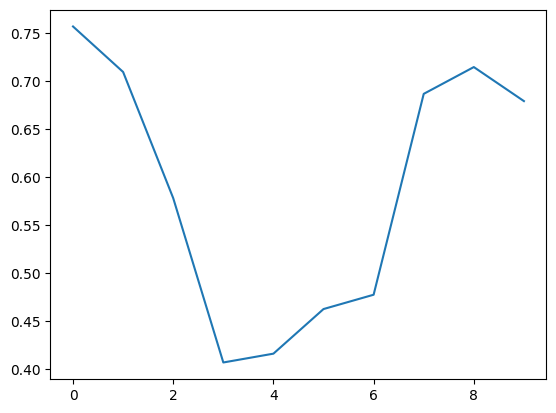

In [61]:
plt.plot(accs.mean(axis = 1))

In [63]:
utils.plot_arr(
    np.append(utils.sampled_verts_from_path("datasets/action_smplx_models/female_run.npz", idx = 0),
            utils.sampled_verts_from_path("datasets/action_smplx_models/female_run.npz", idx = 50), axis = 0)
    )

In [58]:
male_accs = np.copy(accs)

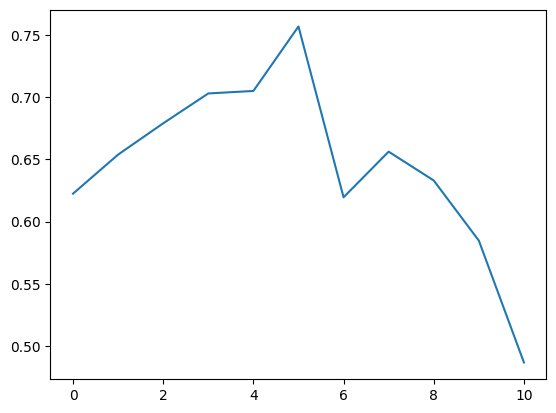

In [57]:
plt.plot(accs.mean(axis = 0))

In [ ]:
points1, faces1 = utils.sampled_verts_from_path("datasets/action_smplx_models/male_run.npz", idx = 0, return_faces=True)

In [158]:
baseline_accs = np.zeros((5, 10))
fgw_accs = np.zeros((5, 10))

dataset_path = "datasets/action_smplx_models"

for i in range(5):
    path = dataset_path + "/" + np.random.choice(os.listdir(dataset_path))
    randidx = np.random.randint(0, int(np.load(path)["mocap_time_length"] * 120) - 105)
    points1, faces1 = utils.sampled_verts_from_path(path, idx = randidx, return_faces=True)
    C1 = scipy.spatial.distance.cdist(points1, points1)#utils.graph_distance_within_cloud_minimally_connected(points1, k = 10)
    for j in range(np.arange(10, 101, 10).shape[0]):
        td = np.arange(10,101,5)[j]
        points2, faces2 = utils.sampled_verts_from_path(path, idx = randidx + td, return_faces=True)
        a = np.ones(1000)/1000
        b = np.ones(1000)/1000
        M = ot.dist(points1, points2)
        G1 = ot.solve(M, a, b).plan
        baseline_accs[i,j] = utils.region_accuracy_adjusted(G1, faces1, faces2)
        C2 = scipy.spatial.distance.cdist(points2, points2)#utils.graph_distance_within_cloud_minimally_connected(points2, k = 10)
        
        G2 = ot.fused_gromov_wasserstein(M, C1, C2, alpha = 0.5)

        fgw_accs[i,j] = utils.region_accuracy_adjusted(G2, faces1, faces2)
        print(i,j,"done")

0 0 done
0 1 done
0 2 done
0 3 done
0 4 done
0 5 done
0 6 done
0 7 done
0 8 done
0 9 done
1 0 done
1 1 done
1 2 done
1 3 done
1 4 done
1 5 done
1 6 done
1 7 done
1 8 done
1 9 done
2 0 done
2 1 done
2 2 done
2 3 done
2 4 done
2 5 done
2 6 done
2 7 done
2 8 done
2 9 done
3 0 done
3 1 done
3 2 done
3 3 done
3 4 done
3 5 done
3 6 done
3 7 done
3 8 done
3 9 done
4 0 done
4 1 done
4 2 done
4 3 done
4 4 done
4 5 done
4 6 done
4 7 done
4 8 done
4 9 done


Text(0, 0.5, 'adjusted accuracy')

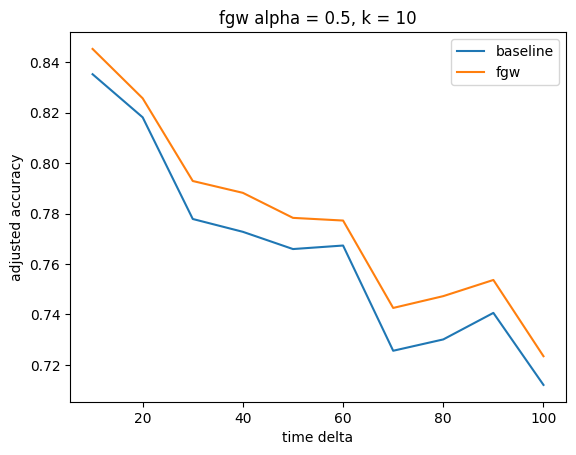

In [159]:
plt.plot(np.arange(10, 101, 10), baseline_accs.mean(axis = 0), label = "baseline")
plt.plot(np.arange(10, 101, 10), fgw_accs.mean(axis = 0), label = "fgw")
plt.legend()
plt.title("fgw alpha = 0.5, k = 10")
plt.xlabel("time delta")
plt.ylabel("adjusted accuracy")

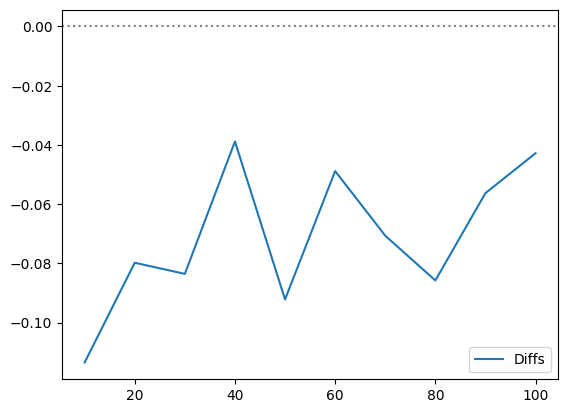

In [107]:
plt.plot(np.arange(10, 101, 10), np.array(fgw_accs.mean(axis = 0)) - np.array(baseline_accs.mean(axis = 0)), label = "Diffs")
plt.axhline(0, color = "gray", linestyle = "dotted")
plt.legend()

In [157]:
N = 10000
points, faces = utils.sampled_verts_from_random_action(return_faces = True, n_points=N)
C = scipy.spatial.distance.cdist(points, points)#utils.graph_distance_within_cloud_minimally_connected(points, k = 999)
utils.plot_arr(points, color = C[np.random.randint(N)], colorbar = True)

Randomly chosen file: male2_Calibration_stageii.npz
Randomly chosen index: 224


In [128]:
mask_regions = ["upper_torso", "lower_torso", "pelvis"]
mask = [x in mask_regions for x in utils.faces_to_regions(faces1)]
c = ["blue" if x else "red" for x in mask]
C = np.cov(points[mask].T)
eigvals, eigvecs = np.linalg.eigh(C)
print(eigvals)
normal = eigvecs[:, 1]
with_torso_mean = np.append(points1, points1[mask].mean(axis = 0).reshape(-1, 3), axis = 0)
with_torso_norm = np.append(with_torso_mean, (points1[mask].mean(axis = 0) + normal).reshape(-1, 3), axis = 0)
utils.plot_arr(with_torso_norm, color = ["blue"] * 1000 + ["red"] + ["green"])
#utils.plot_arr(points1, color = c)

[0.02227211 0.03184884 0.19347342]


In [149]:
eigvals

array([0.022358  , 0.03203993])

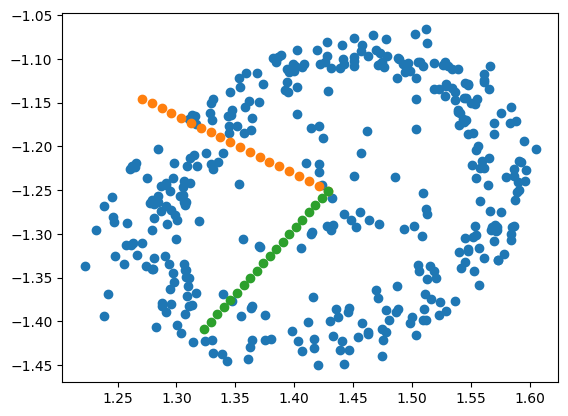

In [148]:
eigvals, eigvecs = np.linalg.eigh(np.cov(points[mask][:,:-1].T))
vec = eigvecs[:, 1]
plt.scatter(points1[mask][:,0], points1[mask][:,1])
plt.scatter(
    [points1[mask][:,0].mean() + vec[0]*x for x in np.arange(0,.2,0.01)],
    [points1[mask][:,1].mean() + vec[1]*x for x in np.arange(0,.2,0.01)]
)
vec = eigvecs[:, 0]
plt.scatter(
    [points1[mask][:,0].mean() + vec[0]*x for x in np.arange(0,.2,0.01)],
    [points1[mask][:,1].mean() + vec[1]*x for x in np.arange(0,.2,0.01)]
)

In [195]:
dataset_path = "datasets/action_smplx_models"

path = dataset_path + "/" + np.random.choice(os.listdir(dataset_path))
randidx = np.random.randint(0, int(np.load(path)["mocap_time_length"] * 120) - 105)
points1, faces1 = utils.sampled_verts_from_path(path, idx = randidx, return_faces=True)
points2, faces2 = utils.sampled_verts_from_path(path, idx = randidx + 50, return_faces=True)

a = np.ones(1000)/1000
b = np.ones(1000)/1000

#G1 = ot.solve(ot.dist(points1, points2), a, b).plan
C1 = utils.graph_distance_within_cloud_minimally_connected(points1)
C2 = utils.graph_distance_within_cloud_minimally_connected(points2)
G1 = ot.gromov_wasserstein(C1, C2)

ordered_faces2 = ((G1 / G1.max()) @ faces2).astype(int)

In [196]:
regions1 = utils.faces_to_regions(faces1)
regions2 = utils.faces_to_regions(ordered_faces2)

In [197]:
np.mean([regions1[i] == regions2[i] for i in range(len(regions1))])

np.float64(0.291)

In [198]:
incorrect_dict = {}

for i in range(len(regions1)):
    if regions1[i] != regions2[i]:
        s = [regions1[i], regions2[i]]
        s = tuple(sorted(s))
        if s in incorrect_dict:
            incorrect_dict[s] += 1
        else:
            incorrect_dict[s] = 0

In [199]:
df = pd.DataFrame(
    data = {
        "reg1": [r[0] for r in incorrect_dict],
        "reg2": [r[1] for r in incorrect_dict],
        "num": incorrect_dict.values()
    }
)

In [200]:
df.sort_values(by = "num", ascending = False)
df["left_right_mixup"] = df["reg1"].apply(lambda x: x[4:]) == df["reg2"].apply(lambda x: x[5:])

In [201]:
df.sort_values("num", ascending = False)

,reg1,reg2,num,left_right_mixup
2,left_shin,right_shin,96,True
4,left_thigh,right_thigh,73,True
6,left_foot,right_foot,52,True
3,head,upper_torso,45,False
9,left_thigh,pelvis,45,False
1,lower_torso,upper_torso,43,False
8,lower_torso,pelvis,41,False
16,right_upper_arm,upper_torso,40,False
21,right_forearm,upper_torso,28,False
7,left_upper_arm,right_forearm,24,False


In [202]:
utils.plot_3d_points_and_connections_region_matched(points1, points2, faces1, faces2, G1)

Region accuracy adjusted: 0.307286166842661
